In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
insurance_data = pd.read_csv("insurance.csv")

In [4]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
gender_map = {
    "male":0,
    "female":1,
}

smoker_map = {
    "yes":1,
    "no":0
}

insurance_data["sex"] = insurance_data["sex"].map(gender_map)

In [6]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


In [7]:
insurance_data["smoker"] = insurance_data["smoker"].map(smoker_map)

In [8]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


<Axes: xlabel='bmi', ylabel='charges'>

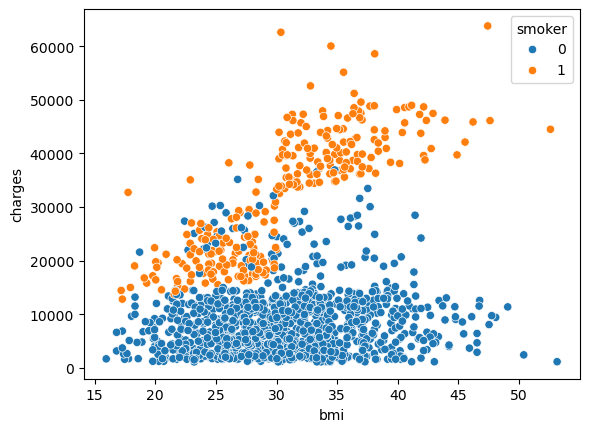

In [9]:
sns.scatterplot(insurance_data,x="bmi",y="charges",hue="smoker")

In [10]:
X=insurance_data.drop(columns=["region","charges"],axis=1)

In [11]:
X

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0
...,...,...,...,...,...
1333,50,0,30.970,3,0
1334,18,1,31.920,0,0
1335,18,1,36.850,0,0
1336,21,1,25.800,0,0


In [12]:
Y = insurance_data["charges"]

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [15]:
X_train.head()

,age,sex,bmi,children,smoker
560,46,1,19.95,2,0
1285,47,1,24.32,0,0
1142,52,1,24.86,0,0
969,39,1,34.32,5,0
486,54,1,21.47,3,0


In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
model = LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [18]:
y_predicted = model.predict(X_test)

In [19]:
y_predicted[:5]

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081])

In [20]:
Y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [21]:
y_predicted

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

# Evaluate

In [22]:
from sklearn.metrics import r2_score

In [23]:
r_squared_value = r2_score(Y_test,y_pred=y_predicted)

In [24]:
r_squared_value

0.7811302113434095

In [25]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r_squared_value = 1- ((1-r_squared_value)*(n-1)/(n-p-1))

In [26]:
r_squared_value,adjusted_r_squared_value

(0.7811302113434095, 0.7769533069797342)

In [27]:
X_test.shape

(268, 5)

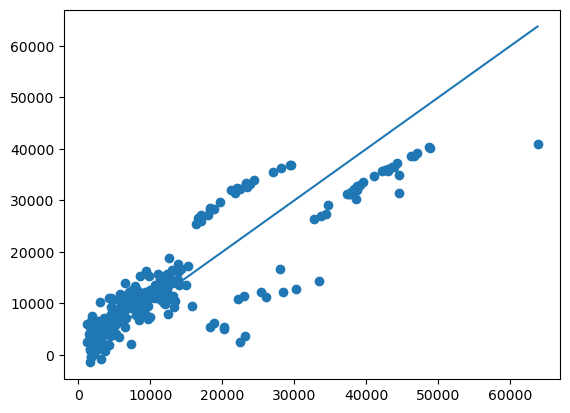

In [28]:
plt.scatter(Y_test,y_predicted)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()])

# One hot encoding

In [29]:
x = insurance_data.drop(columns=["charges"])
Y = insurance_data["charges"]
X
X = pd.get_dummies(x,columns=["region"],drop_first=True,dtype=int)

In [30]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [31]:
model = LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [32]:
y_pred = model.predict(X_test)

In [33]:
r2 = r2_score(Y_test,y_pred=y_pred)
print(r2)

0.7835929767120724


In [34]:
x = insurance_data.drop(columns=["charges"])
Y = insurance_data["charges"]
X
X = pd.get_dummies(x,columns=["region"],drop_first=True,dtype=int)
X["age_smoker"] = X["age"]*X["smoker"]
X["bmi_smoker"] = X["bmi"]*X["smoker"]

In [35]:
X

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.90
1,18,0,33.770,1,0,0,1,0,0,0.00
2,28,0,33.000,3,0,0,1,0,0,0.00
3,33,0,22.705,0,0,1,0,0,0,0.00
4,32,0,28.880,0,0,1,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,1,0,0,0,0.00
1334,18,1,31.920,0,0,0,0,0,0,0.00
1335,18,1,36.850,0,0,0,1,0,0,0.00
1336,21,1,25.800,0,0,0,0,1,0,0.00


In [36]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [37]:
model = LinearRegression()
model.fit(X_train,Y_train)
y_pred = model.predict(X_test)
r2 = r2_score(Y_test,y_pred=y_pred)
r2

y_pred[:5]

array([11244.92252985,  7419.09613036, 33108.56263345, 10825.70349972,
       28165.83120369])

In [38]:
Y_test[:5]

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
Name: charges, dtype: float64

In [49]:
Y_train_pred = model.predict(X_train)
r2_train =r2_score(Y_train,Y_train_pred)
r2,r2_train
X_test["bmi"]
Y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

<Axes: xlabel='bmi', ylabel='charges'>

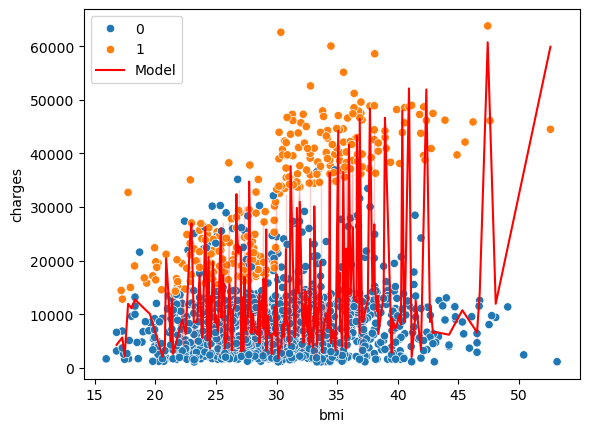

In [ ]:
# Sort by bmi to show the curve properly
test_df = X_test.copy()
test_df['predictions'] = y_pred
test_df = test_df.sort_values('bmi')

sns.scatterplot(insurance_data, x="bmi", y="charges", hue="smoker")
sns.lineplot(x=test_df["bmi"], y=test_df['predictions'], color='red', label='Model')

<Axes: xlabel='bmi', ylabel='predictions'>

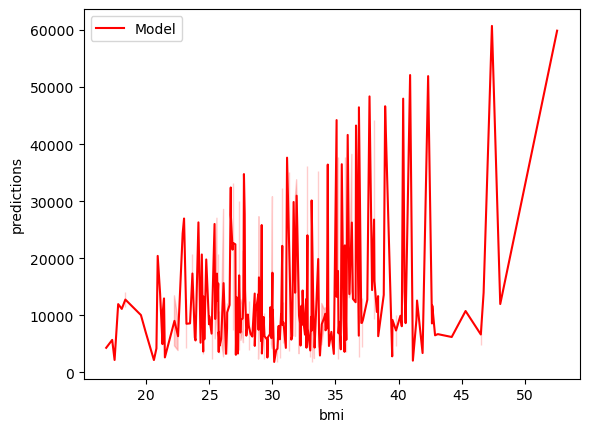

In [52]:
sns.lineplot(x=test_df["bmi"], y=test_df['predictions'], color='red', label='Model')